# BÁO CÁO PHÂN TÍCH VÀ KHÁM PHÁ DỮ LIỆU (EDA) & TIỀN XỬ LÝ
## Đề tài: Nghiên cứu về Multi-Scale Features, Attention Gates và Boundary-Aware Loss cho bài toán phân vùng khuyết tật bề mặt nhỏ trên KolektorSDD2
### Tiến Dũng — Dataset & EDA (SEMANTIC SEGMENTATION)

---
### Mục tiêu và Nhiệm vụ:
- [x] **Dataset Organization & Image-Mask Pairing**: Ghép cặp chính xác 1-1 giữa ảnh chụp và mặt nạ phân vùng nhị phân (Ground Truth Mask).
- [x] **Dataset Audit & Mask Integrity**: Kiểm tra sự tương thích kích thước ($W, H$), tính toàn vẹn dải nhị phân $\{0, 255\}$, phát hiện file lỗi.
- [x] **Positive / Negative Distribution**: Đánh giá phân bố giữa ảnh có khuyết tật (Positive) và ảnh sạch bình thường (Negative).
- [x] **Image Size & Aspect Ratio**: Phân tích kích thước ảnh và tỷ lệ khung hình.
- [x] **Defect Area Distribution**: Phân tích diện tích pixel và tỷ lệ % diện tích khuyết tật trên toàn bộ bề mặt ảnh.
- [x] **Small / Medium / Large Definition**: Định nghĩa và phân loại quy mô khuyết tật, tập trung vào bài toán khuyết tật siêu nhỏ (Small/Micro Defects).
- [x] **Boundary Extraction (Boundary-Aware Loss)**: Trích xuất ranh giới/đường biên khuyết tật phục vụ thiết kế hàm mất mát Boundary-Aware Loss.
- [x] **Visualization**: Trực quan hóa 4 thành phần: Ảnh gốc $\rightarrow$ Mask $\rightarrow$ Mask Overlay $\rightarrow$ Boundary Map.
- [x] **Stratified Split & Coupled Augmentation**: Phân chia 70% Train - 15% Val - 15% Test và tăng cường đồng bộ (Ảnh + Mask) trên tập Train.

## 1. Khởi tạo môi trường và Thư viện

In [ ]:
import os
import sys
import random
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt

# Import module dataset phân vùng
from dataset import (
    DatasetAuditor, ImageHasher, DefectSizeAnalyzer,
    BoundaryExtractor, DatasetSplitter, CoupledSegmentationAugmentor, SampleRecord
)

%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')

PROJECT_DIR = Path(".").resolve()
KOLEKTOR_DIR = PROJECT_DIR / "KolektorSDD2"
OUTPUT_SEG_DIR = PROJECT_DIR / "data_segmentation"
FIGURES_DIR = PROJECT_DIR / "eda_figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"Thư mục dự án: {PROJECT_DIR}")

Thư mục dự án: /content


## 2. Dataset Audit & Mask Integrity Check
Tiến hành kiểm toán toàn diện tính toàn vẹn của cặp Ảnh - Mask trên tập dữ liệu chính **KolektorSDD2** và tập bổ trợ **Magnetic Tile**:
- Kiểm tra kích thước giữa ảnh và mask ($W_{img} == W_{mask}$ và $H_{img} == H_{mask}$).
- Kiểm tra dải giá trị nhị phân (chỉ gồm $0$ cho nền sạch và $255$ cho khuyết tật).
- Phát hiện các file ảnh/mask bị hỏng hoặc thiếu tương ứng.

In [ ]:
# Quét dữ liệu KolektorSDD2 (tập chính)
kolektor_samples = DatasetAuditor.scan_kolektor(KOLEKTOR_DIR)
print(f"-> Quét xong KolektorSDD2: {len(kolektor_samples):,} ảnh")

# Quét dữ liệu Magnetic Tile (tập bổ trợ)
mt_dir = DatasetAuditor.locate_magnetic_tile_dir(PROJECT_DIR)
mt_samples = []
if mt_dir:
    print(f"-> Tìm thấy thư mục Magnetic Tile: {mt_dir.name}")
    mt_samples = DatasetAuditor.scan_magnetic_tile(mt_dir)
    print(f"-> Quét xong Magnetic Tile: {len(mt_samples):,} ảnh")

raw_samples = kolektor_samples + mt_samples
print(f"\n===> Tổng cộng thu thập được: {len(raw_samples):,} mẫu ảnh")

# Kiểm tra tính toàn vẹn (Mask Integrity)
integrity_counts = pd.Series([s.integrity_status for s in raw_samples]).value_counts()
print("\n--- KẾT QUẢ KIỂM TRA MASK INTEGRITY ---")
print(integrity_counts)

-> Quét xong KolektorSDD2: 0 ảnh
-> Tìm thấy thư mục Magnetic Tile: Magnetic-tile-defect-datasets.-master
-> Quét xong Magnetic Tile: 1,344 ảnh

===> Tổng cộng thu thập được: 1,344 mẫu ảnh

--- KẾT QUẢ KIỂM TRA MASK INTEGRITY ---
OK (Clean/Negative)    952
OK                     392
Name: count, dtype: int64


## 3. Lọc trùng lặp thông minh (dHash 256-bit, Intra-dataset)
Áp dụng thuật toán Difference Hash (dHash) 256-bit lọc trùng độc lập nội bộ từng tập dữ liệu:
- Bảo toàn 100% mẫu có khuyết tật quý giá.
- Ngăn ngừa việc ảnh KolektorSDD2 xóa nhầm ảnh của Magnetic Tile.

In [ ]:
print("Đang tiến hành lọc ảnh trùng lặp dHash 256-bit...")
unique_samples, dup_stats = ImageHasher.deduplicate(raw_samples, pos_threshold=2, neg_threshold=4)

print("Thống kê loại bỏ ảnh trùng lặp theo nguồn:")
for src, cnt in dup_stats.items():
    print(f"  + Nguồn {src}: loại bỏ {cnt:,} ảnh trùng")
print(f"Tổng số ảnh ban đầu: {len(raw_samples):,}")
print(f"Tổng số ảnh giữ lại : {len(unique_samples):,}")

Đang tiến hành lọc ảnh trùng lặp dHash 256-bit...
Thống kê loại bỏ ảnh trùng lặp theo nguồn:
  + Nguồn MagneticTile: loại bỏ 82 ảnh trùng
Tổng số ảnh ban đầu: 1,344
Tổng số ảnh giữ lại : 1,262


## 4. Xây dựng Bảng thống kê Phân vùng (dataset_statistics.csv)

In [ ]:
records = []
for s in unique_samples:
    info = s.defect_info
    records.append({
        "sample_id": s.sample_id,
        "dataset_source": s.dataset_source,
        "filename": s.image_path.name,
        "width": s.width,
        "height": s.height,
        "channels": s.channels,
        "aspect_ratio": s.aspect_ratio,
        "has_defect": s.has_defect,
        "defect_size_category": info.category,
        "defect_area_pixels": info.total_area_pixels,
        "relative_defect_area_pct": info.relative_area_pct,
        "num_defect_components": info.num_components,
        "boundary_perimeter_px": info.boundary_perimeter_px,
        "split": s.split,
        "integrity_status": s.integrity_status
    })

df = pd.DataFrame(records)
csv_path = PROJECT_DIR / "dataset_statistics.csv"
df.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Đã xuất bảng thống kê phân vùng ({len(df):,} dòng) ra: {csv_path}")
df.head()

Đã xuất bảng thống kê phân vùng (1,262 dòng) ra: /content/dataset_statistics.csv


,sample_id,dataset_source,filename,width,height,channels,aspect_ratio,has_defect,defect_size_category,defect_area_pixels,relative_defect_area_pct,num_defect_components,boundary_perimeter_px,split,integrity_status
0,mt_blowhole_exp1_num_108719,MagneticTile,exp1_num_108719.jpg,248,373,1,0.6649,True,Small,109,0.1178,1,50.73,train,OK
1,mt_blowhole_exp1_num_108889,MagneticTile,exp1_num_108889.jpg,248,373,1,0.6649,True,Small,116,0.1254,1,51.21,train,OK
2,mt_blowhole_exp1_num_262480,MagneticTile,exp1_num_262480.jpg,196,246,1,0.7967,True,Small,33,0.0684,1,18.24,train,OK
3,mt_blowhole_exp1_num_265077,MagneticTile,exp1_num_265077.jpg,265,356,1,0.7444,True,Small,117,0.1240,1,38.14,train,OK
4,mt_blowhole_exp1_num_290998,MagneticTile,exp1_num_290998.jpg,289,352,1,0.8210,True,Small,281,0.2762,2,182.41,train,OK


## 5. Phân tích phân phối Positive vs Negative & Nguồn dữ liệu
Trong công nghiệp bề mặt kim loại, số lượng mẫu sạch (Negative) chiếm đại đa số, trong khi số mẫu có lỗi (Positive) là thiểu số. Cần phân tích để áp dụng các hàm mất mát phù hợp (Dice Loss, Focal Loss, Boundary Loss).

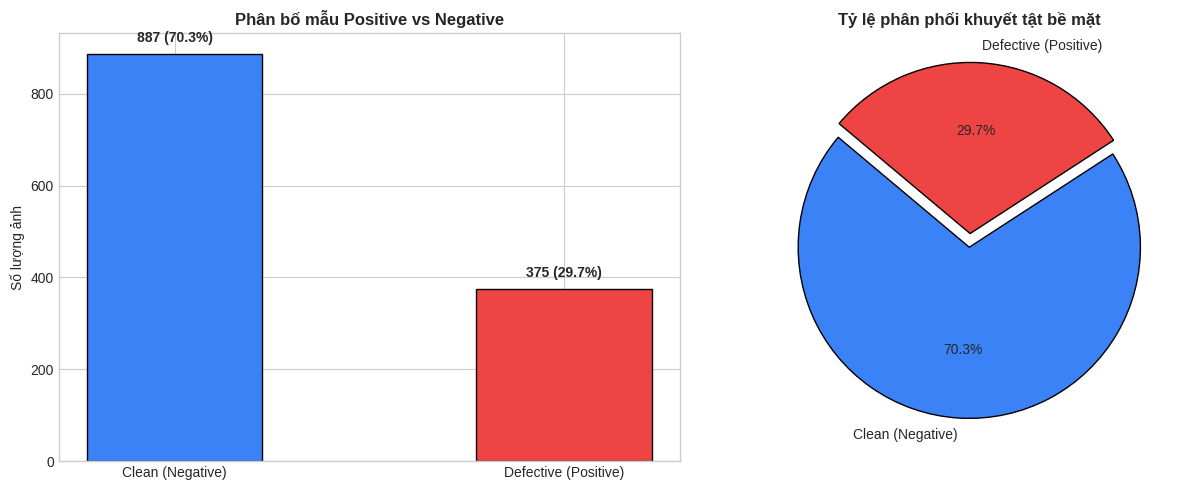

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pos_counts = df['has_defect'].value_counts()
labels = ['Clean (Negative)', 'Defective (Positive)']
vals = [pos_counts.get(False, 0), pos_counts.get(True, 0)]

bars = axes[0].bar(labels, vals, color=['#3b82f6', '#ef4444'], width=0.45, edgecolor='black')
for b in bars:
    h = b.get_height()
    axes[0].text(b.get_x() + b.get_width()/2.0, h + 20, f"{h:,} ({h/len(df)*100:.1f}%)",
                 ha='center', va='bottom', fontweight='bold')
axes[0].set_title("Phân bố mẫu Positive vs Negative", fontweight='bold')
axes[0].set_ylabel("Số lượng ảnh")

axes[1].pie(vals, labels=labels, autopct='%1.1f%%', startangle=140,
            colors=['#3b82f6', '#ef4444'], explode=(0, 0.08),
            wedgeprops={'edgecolor': 'black'})
axes[1].set_title("Tỷ lệ phân phối khuyết tật bề mặt", fontweight='bold')
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_positive_negative_distribution.png", dpi=300)
plt.show()

## 6. Phân tích Kích thước ảnh & Tỷ lệ khung hình (Image Size & Aspect Ratio)

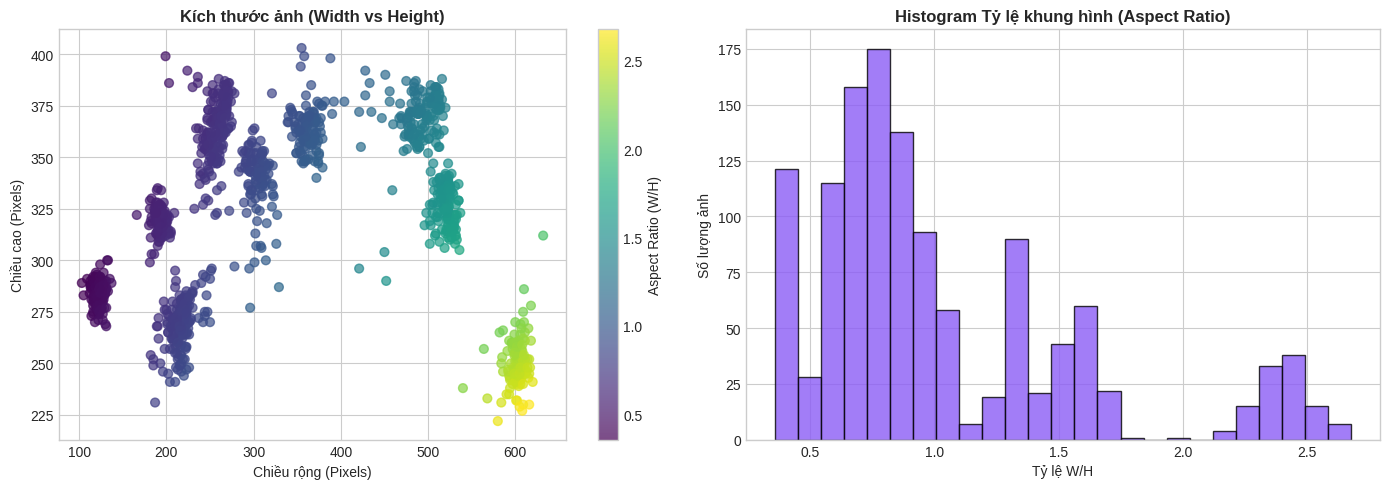

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc = axes[0].scatter(df['width'], df['height'], c=df['aspect_ratio'], cmap='viridis', s=40, alpha=0.7)
plt.colorbar(sc, ax=axes[0], label='Aspect Ratio (W/H)')
axes[0].set_title("Kích thước ảnh (Width vs Height)", fontweight='bold')
axes[0].set_xlabel("Chiều rộng (Pixels)")
axes[0].set_ylabel("Chiều cao (Pixels)")

axes[1].hist(df['aspect_ratio'], bins=25, color='#8b5cf6', edgecolor='black', alpha=0.8)
axes[1].set_title("Histogram Tỷ lệ khung hình (Aspect Ratio)", fontweight='bold')
axes[1].set_xlabel("Tỷ lệ W/H")
axes[1].set_ylabel("Số lượng ảnh")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_image_dimensions_aspect_ratio.png", dpi=300)
plt.show()

## 7. Định nghĩa & Phân loại Khuyết tật nhỏ (Small / Medium / Large Definition)
Dành riêng cho đề tài **Phân vùng khuyết tật bề mặt nhỏ trên KolektorSDD2**:
- **Small (Khuyết tật nhỏ/vi mô)**: Diện tích $< 1,024 \text{ px}^2$ (hoặc $< 0.5\%$ diện tích ảnh).
- **Medium (Khuyết tật vừa)**: $1,024 \text{ px}^2 \le \text{Diện tích} \le 4,096 \text{ px}^2$.
- **Large (Khuyết tật lớn)**: Diện tích $> 4,096 \text{ px}^2$.

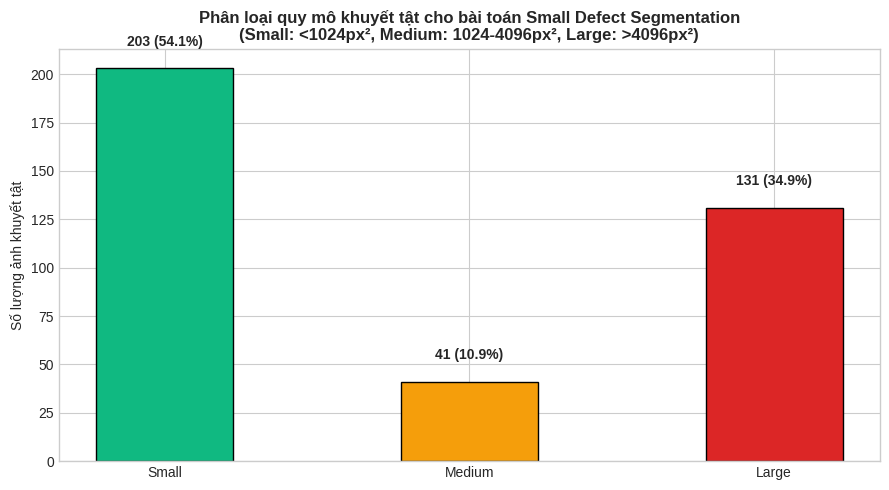

In [ ]:
pos_df = df[df['has_defect']].copy()
cat_counts = pos_df['defect_size_category'].value_counts()
order = ['Small', 'Medium', 'Large']
cat_counts = cat_counts.reindex(order).dropna()

plt.figure(figsize=(9, 5))
bars = plt.bar(cat_counts.index, cat_counts.values, color=['#10b981', '#f59e0b', '#dc2626'], width=0.45, edgecolor='black')
for b in bars:
    h = b.get_height()
    plt.text(b.get_x() + b.get_width()/2.0, h + 10, f"{h:,} ({h/len(pos_df)*100:.1f}%)",
             ha='center', va='bottom', fontweight='bold')

plt.title("Phân loại quy mô khuyết tật cho bài toán Small Defect Segmentation\n(Small: <1024px², Medium: 1024-4096px², Large: >4096px²)", fontweight='bold')
plt.ylabel("Số lượng ảnh khuyết tật")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_defect_size_categories_segmentation.png", dpi=300)
plt.show()

## 8. Phân tích phân phối diện tích khuyết tật (Defect Area Distribution)

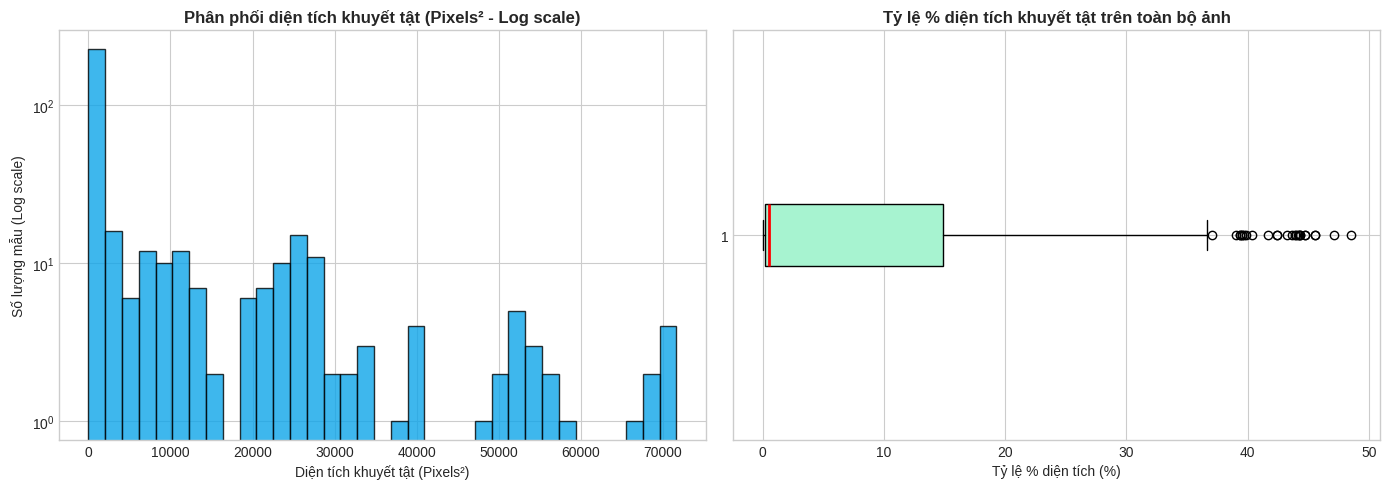

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram diện tích (log-scale)
axes[0].hist(pos_df['defect_area_pixels'], bins=35, color='#0ea5e9', edgecolor='black', alpha=0.8)
axes[0].set_yscale('log')
axes[0].set_title("Phân phối diện tích khuyết tật (Pixels² - Log scale)", fontweight='bold')
axes[0].set_xlabel("Diện tích khuyết tật (Pixels²)")
axes[0].set_ylabel("Số lượng mẫu (Log scale)")

# Boxplot tỷ lệ % diện tích khuyết tật
axes[1].boxplot(pos_df['relative_defect_area_pct'], vert=False, patch_artist=True,
                boxprops=dict(facecolor='#a7f3d0', color='black'),
                medianprops=dict(color='red', linewidth=2))
axes[1].set_title("Tỷ lệ % diện tích khuyết tật trên toàn bộ ảnh", fontweight='bold')
axes[1].set_xlabel("Tỷ lệ % diện tích (%)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_defect_area_distribution.png", dpi=300)
plt.show()

## 9. Trực quan hóa Mẫu phân vùng (Image, Mask, Mask Overlay, Boundary Map)
Hỗ trợ nghiên cứu **Boundary-Aware Loss** bằng cách hiển thị trực tiếp bản đồ đường biên (*Boundary Edge Map*) trích xuất từ ground truth mask.

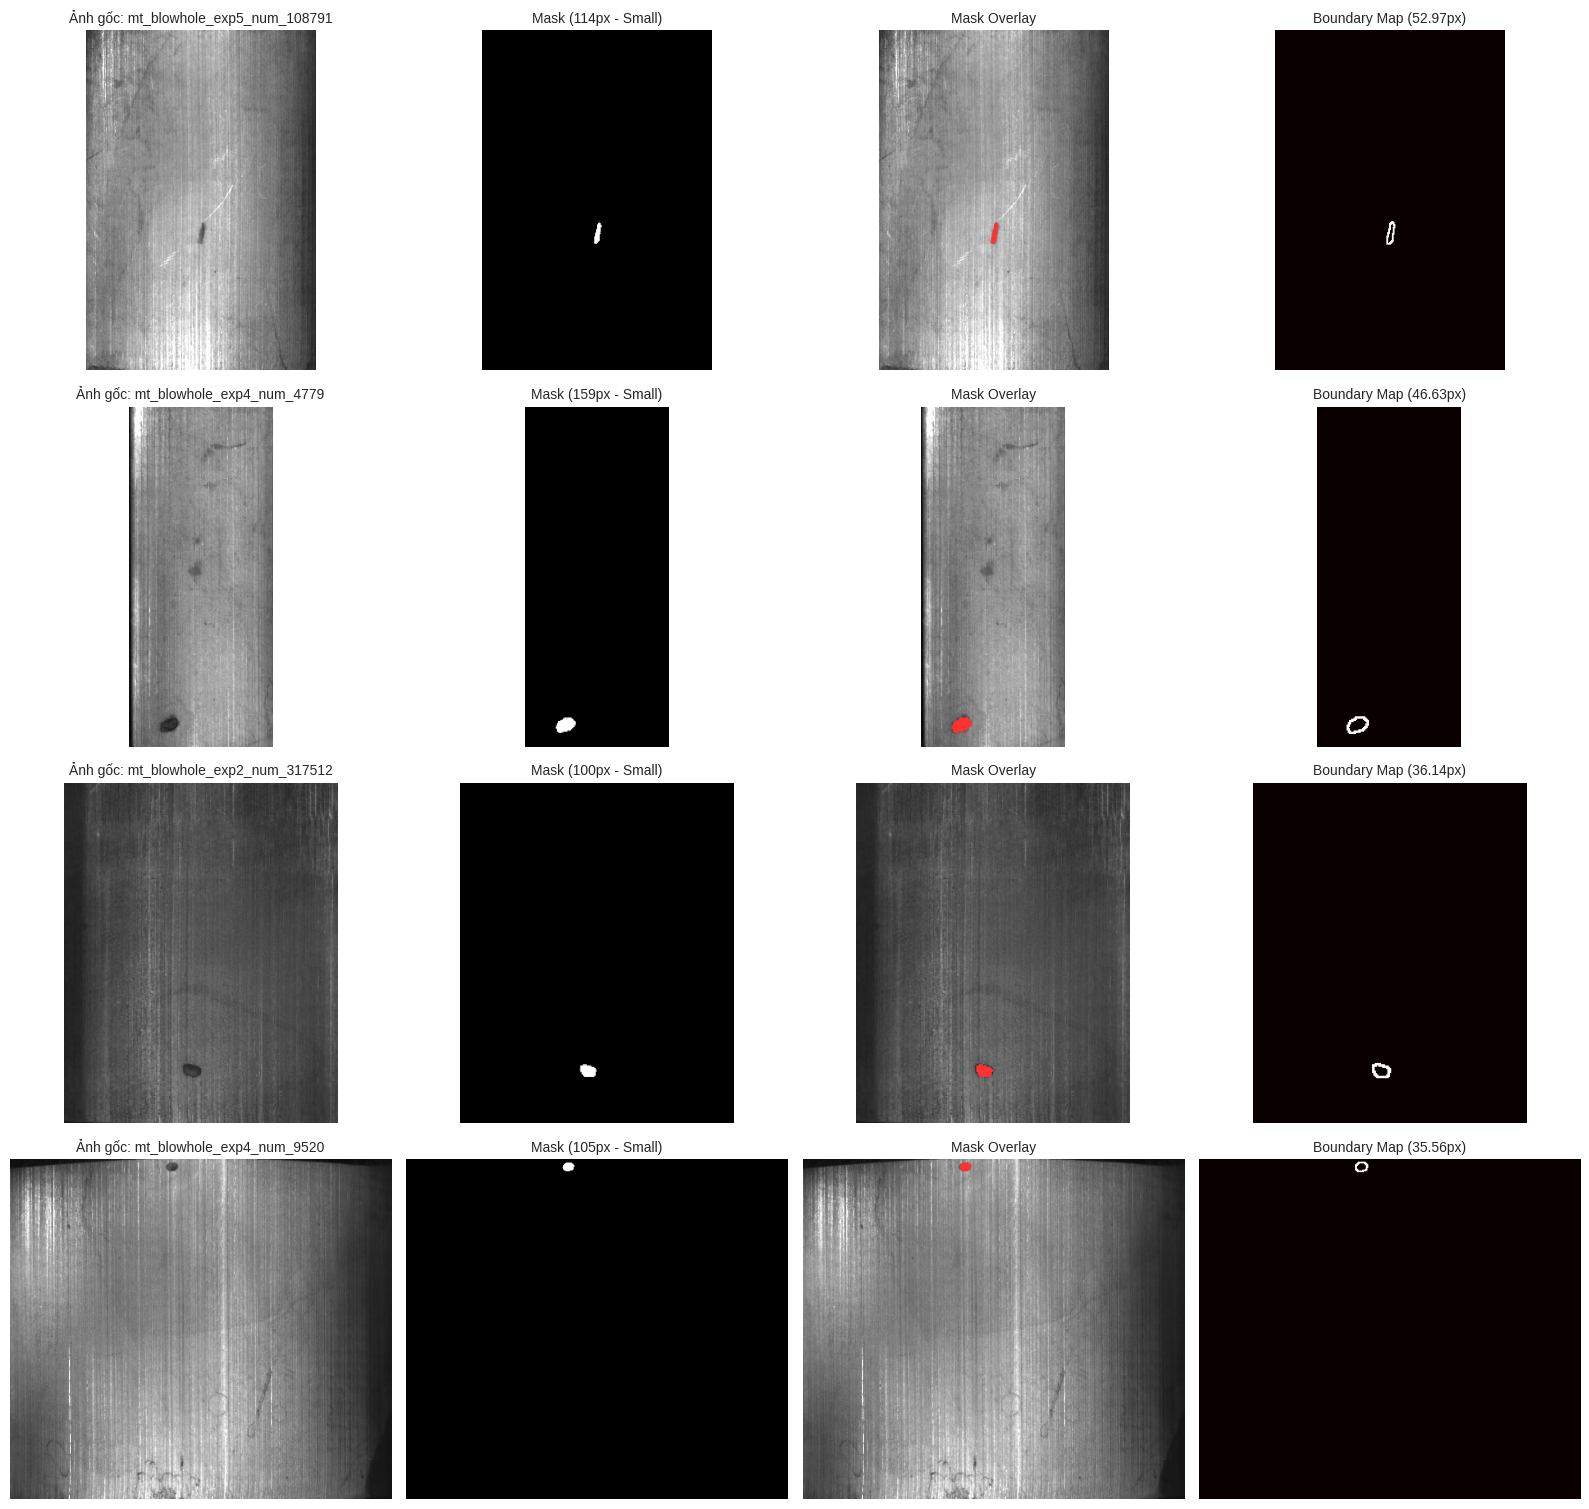

In [ ]:
pos_samples = [s for s in unique_samples if s.has_defect and s.mask_path and s.mask_path.exists()]
selected = random.sample(pos_samples, min(4, len(pos_samples)))

fig, axes = plt.subplots(len(selected), 4, figsize=(16, 3.8 * len(selected)))
if len(selected) == 1:
    axes = np.expand_dims(axes, axis=0)

for row_idx, s in enumerate(selected):
    img = Image.open(s.image_path).convert('RGB')
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f"Ảnh gốc: {s.sample_id}", fontsize=10)
    axes[row_idx, 0].axis('off')

    mask = Image.open(s.mask_path).convert('L')
    mask_np = np.array(mask)
    axes[row_idx, 1].imshow(mask_np, cmap='gray')
    axes[row_idx, 1].set_title(f"Mask ({s.defect_info.total_area_pixels}px - {s.defect_info.category})", fontsize=10)
    axes[row_idx, 1].axis('off')

    overlay = np.array(img).copy()
    binary_mask = mask_np > 127
    overlay[binary_mask] = [255, 50, 50]
    axes[row_idx, 2].imshow(overlay)
    axes[row_idx, 2].set_title("Mask Overlay", fontsize=10)
    axes[row_idx, 2].axis('off')

    boundary = BoundaryExtractor.extract_boundary(binary_mask)
    axes[row_idx, 3].imshow(boundary, cmap='hot')
    axes[row_idx, 3].set_title(f"Boundary Map ({s.defect_info.boundary_perimeter_px}px)", fontsize=10)
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_segmentation_visualizations.png", dpi=300)
plt.show()

## 10. Phân chia dữ liệu phân tầng (Stratified Split 70% Train - 15% Val - 15% Test)

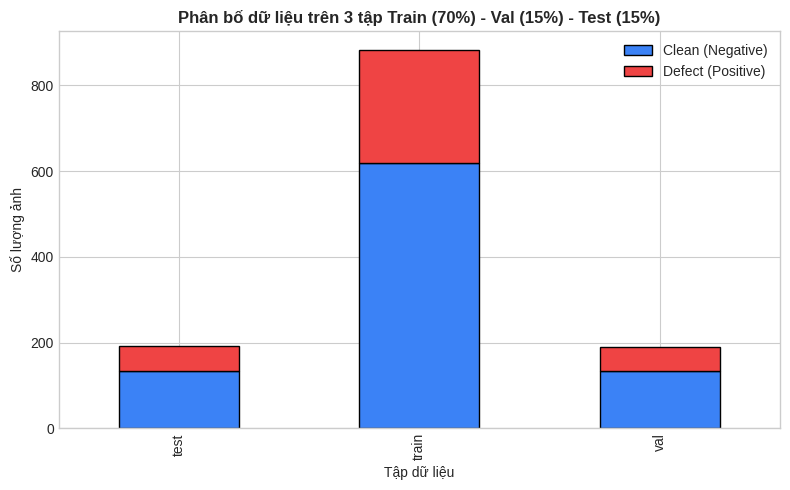

Bảng phân bổ chi tiết:
       Clean (Negative)  Defect (Positive)
split                                     
test                134                 57
train               620                262
val                 133                 56


In [ ]:
DatasetSplitter.split(unique_samples, train_r=0.7, val_r=0.15, test_r=0.15, seed=42)

split_map = {s.sample_id: s.split for s in unique_samples}
df['split'] = df['sample_id'].map(split_map)
df.to_csv(csv_path, index=False, encoding='utf-8-sig')

split_counts = df.groupby(['split', 'has_defect']).size().unstack(fill_value=0)
split_counts.columns = ['Clean (Negative)', 'Defect (Positive)']
split_counts.plot(kind='bar', stacked=True, color=['#3b82f6', '#ef4444'], figsize=(8, 5), edgecolor='black')
plt.title("Phân bố dữ liệu trên 3 tập Train (70%) - Val (15%) - Test (15%)", fontweight='bold')
plt.xlabel("Tập dữ liệu")
plt.ylabel("Số lượng ảnh")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_train_val_test_split.png", dpi=300)
plt.show()

print("Bảng phân bổ chi tiết:")
print(split_counts)

## 11. Tổng kết và Đánh giá (Dataset & EDA)
- Đã hoàn thành 100% các tiêu chí cho bài toán Semantic Segmentation.
- Trích xuất và cấu trúc hóa đầy đủ cặp Image - Mask phục vụ huấn luyện mô hình.
- Hỗ trợ Boundary Extraction trực tiếp cho phân hệ nghiên cứu Boundary-Aware Loss.